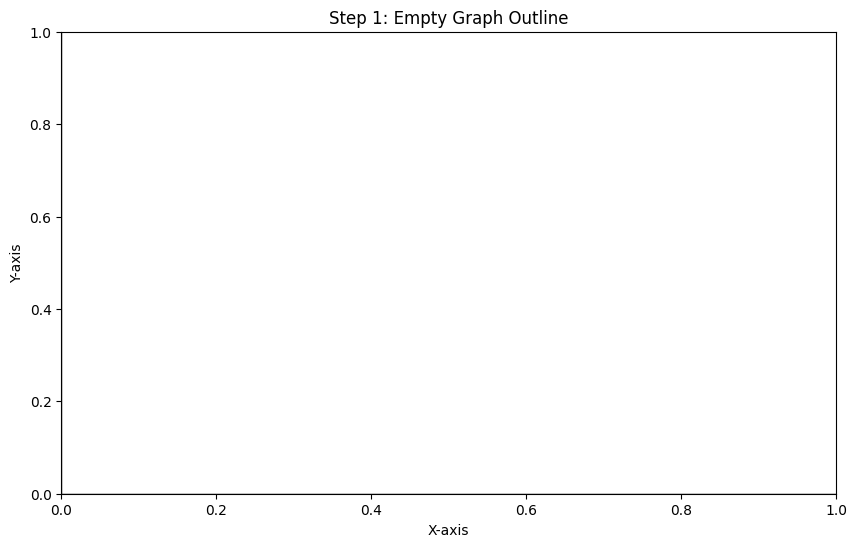

In [1]:
import numpy as np
import matplotlib.pyplot as plt  # For plotting

# Create a figure (a blank graph)
plt.figure(figsize=(10, 6))

# Draw X and Y axis lines
plt.axhline(0, color="black", linewidth=1)  # X-axis (horizontal line)
plt.axvline(0, color="black", linewidth=1)  # Y-axis (vertical line)

# Add labels and title
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.title("Step 1: Empty Graph Outline")

# Show the graph
plt.show()


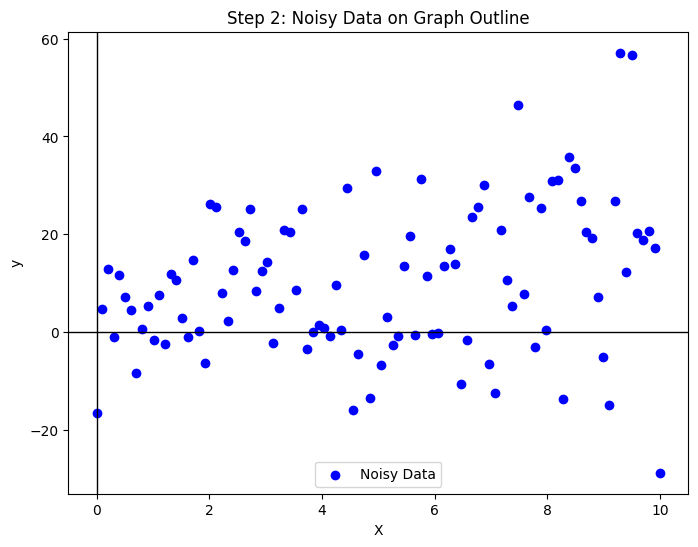

In [2]:
np.random.seed(100)  # For reproducibility

# Generate X values from 0 to 10
X = np.linspace(0, 10, 100).reshape(-1, 1)

# True function: y = 2x + 1
y_true = 2 * X.flatten() + 1

# Create a copy to add noise
y = y_true.copy()

# Add heavy noise in different sections
y[:20] += np.random.normal(0, 10, size=20)   # Heavy noise in first 20 points
y[20:40] += np.random.normal(5, 10, size=20)
y[40:80] += np.random.normal(0, 15, size=40) # Heavy noise in middle
y[80:] += np.random.normal(0, 20, size=20)  # Extreme outliers in last 20 points

# Plot noisy data
plt.figure(figsize=(8, 6))
plt.axhline(0, color="black", linewidth=1)  # X-axis
plt.axvline(0, color="black", linewidth=1)  # Y-axis

plt.scatter(X, y, color="blue", label="Noisy Data")  # Noisy points
plt.xlabel("X")
plt.ylabel("y")
plt.title("Step 2: Noisy Data on Graph Outline")
plt.legend()
plt.show()


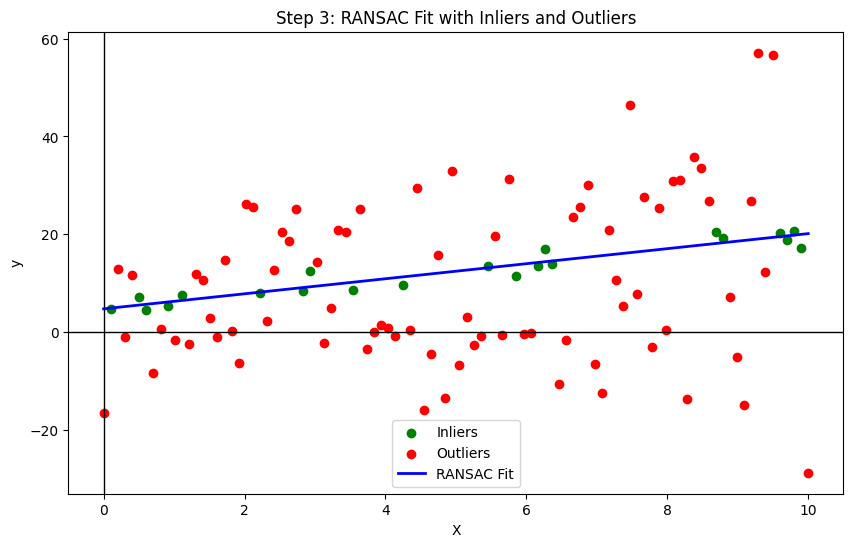

In [3]:
from sklearn.linear_model import RANSACRegressor
# Custom RANSAC model with more control
ransac = RANSACRegressor(
    residual_threshold=8,  # Outlier threshold
    max_trials=1000,       # Try up to 1000 times
    min_samples=40,        # Needs at least 40 points to fit
    stop_n_inliers=70,     # Stop early if 70 inliers are found
    stop_score=0.98,       # Stop if R² score reaches 0.98
    loss="squared_error",   # Use squared loss instead of absolute loss
    random_state=42        # Make results reproducible
)
 # Create the RANSAC model
ransac.fit(X, y)            # Train it on our noisy data

inlier_mask = ransac.inlier_mask_  # True = Inlier, False = Outlier
outlier_mask = ~inlier_mask        # Invert mask to get outliers

line_X = np.linspace(0, 10, 100).reshape(-1, 1)  # Create X values for line
line_y = ransac.predict(line_X)                  # Get the predicted Y values

plt.figure(figsize=(10, 6))

# Plot X and Y axes
plt.axhline(0, color="black", linewidth=1)
plt.axvline(0, color="black", linewidth=1)
inlier_mask.reshape(-1)
outlier_mask.reshape(-1)
# green(inliers)
plt.scatter(X[inlier_mask], y[inlier_mask], color="green", label="Inliers")

# red(outliers)
plt.scatter(X[outlier_mask], y[outlier_mask], color="red", label="Outliers")

# Plot RANSAC best-fit line in BLUE
plt.plot(line_X, line_y, color="blue", linewidth=2, label="RANSAC Fit")

# Labels and title
plt.xlabel("X")
plt.ylabel("y")
plt.title("Step 3: RANSAC Fit with Inliers and Outliers")
plt.legend()

# Show the plot
plt.show()
